# (14) GRA — figs vision (CIFAR10)


project = ```GRA```, host = ```any```, device = ```any```


In [1]:
# HIDE CODE


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

# GitHub 
from gra.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
def plot_optimizer_comparison(
    grouped_data: dict,
    save_path: str = None,
    figsize: tuple = (10, 10),
    zoom_start_iter: int = 60000,
    color_map: dict = None,
    ylims: list = None, ):
    """
    Plot eval/acc and eval/loss for grouped runs.
    
    Args:
        grouped_data: Dict with optimizer names as keys
                      values are lists of {'seed': int, 'history': DataFrame, 'config': dict}
        save_path: Optional path to save figure
        figsize: Figure size
        zoom_start_iter: Starting iteration for zoomed-in plots (second row)
        color_map: Optional dict mapping optimizer names to colors
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    # Default color cycle if no color_map provided
    default_colors = plt.cm.tab10.colors
    
    # Plot each group
    for idx, (key, runs) in enumerate(grouped_data.items()):
        # Choose color: custom map > default cycle
        if color_map and key in color_map:
            color = color_map[key]
        else:
            color = default_colors[idx % len(default_colors)]
        
        # Collect curves across seeds
        acc_curves = []
        loss_curves = []
        
        for run in runs:
            h = run['history']
            
            # Get eval data (drop NaN rows)
            eval_data = h[['iter', 'eval/acc', 'eval/loss']].dropna()
            if len(eval_data) == 0:
                continue
            
            iters = eval_data['iter'].values
            acc_curves.append((iters, eval_data['eval/acc'].values))
            loss_curves.append((iters, eval_data['eval/loss'].values))
        
        if len(acc_curves) == 0:
            continue
        
        # Align curves to common iteration points
        common_iters = acc_curves[0][0]  # assume all have same eval points
        
        acc_matrix = np.array([c[1] for c in acc_curves])
        loss_matrix = np.array([c[1] for c in loss_curves])
        
        acc_mean = acc_matrix.mean(axis=0)
        acc_std = acc_matrix.std(axis=0)
        loss_mean = loss_matrix.mean(axis=0)
        loss_std = loss_matrix.std(axis=0)
        
        # Row 0: Full range
        axes[0, 0].plot(common_iters, acc_mean, color=color, label=key, linewidth=2)
        axes[0, 0].fill_between(common_iters, acc_mean - acc_std, acc_mean + acc_std,
                                color=color, alpha=0.2)
        
        axes[0, 1].plot(common_iters, loss_mean, color=color, label=key, linewidth=2)
        axes[0, 1].fill_between(common_iters, loss_mean - loss_std, loss_mean + loss_std,
                                color=color, alpha=0.2)
        
        # Row 1: Zoomed in (from zoom_start_iter onwards)
        zoom_mask = common_iters >= zoom_start_iter
        if zoom_mask.any():
            zoom_iters = common_iters[zoom_mask]
            zoom_acc_mean = acc_mean[zoom_mask]
            zoom_acc_std = acc_std[zoom_mask]
            zoom_loss_mean = loss_mean[zoom_mask]
            zoom_loss_std = loss_std[zoom_mask]
            
            axes[1, 0].plot(zoom_iters, zoom_acc_mean, color=color, label=key, linewidth=2)
            axes[1, 0].fill_between(zoom_iters, zoom_acc_mean - zoom_acc_std, zoom_acc_mean + zoom_acc_std,
                                    color=color, alpha=0.2)
            
            axes[1, 1].plot(zoom_iters, zoom_loss_mean, color=color, label=key, linewidth=2)
            axes[1, 1].fill_between(zoom_iters, zoom_loss_mean - zoom_loss_std, zoom_loss_mean + zoom_loss_std,
                                    color=color, alpha=0.2)
    
    # Formatting - Row 0 (full range)
    axes[0, 0].set_xlabel('')
    axes[0, 0].set_ylabel('Eval Accuracy (%)')
    axes[0, 0].set_title('Validation Accuracy')
    axes[0, 0].legend(loc='lower right')
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].set_xlabel('')
    axes[0, 1].set_ylabel('Eval Loss')
    axes[0, 1].set_title('Validation Loss')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Formatting - Row 1 (zoomed)
    axes[1, 0].set_xlabel('Iteration')
    axes[1, 0].set_ylabel('Eval Accuracy (%)')
    axes[1, 0].set_title(f'Validation Accuracy (from iter {zoom_start_iter})')
    axes[1, 0].legend(loc='lower right')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].set_xlabel('Iteration')
    axes[1, 1].set_ylabel('Eval Loss')
    axes[1, 1].set_title(f'Validation Loss (from iter {zoom_start_iter})')
    axes[1, 1].grid(True, alpha=0.3)
    
    if ylims is not None:
        for idx, ylim in enumerate(ylims):
            i, j = idx // 2, idx % 2
            axes[i, j].set_ylim(ylim)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()
    return fig, axes

In [3]:
from gra.experiments.wandb_analysis import *


df = fetch_runs(entity='pal-lab', project='GRA-CIFAR10')
summary = get_optimizer_summary(df)  # aggregates across seeds
best_per_opt = compare_optimizers(df, metric='best_val_acc')

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: hadivafaii (poisson-collab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Fetching runs from: pal-lab/GRA-CIFAR10
Found 700 runs
Processed 698 runs (after filtering)


In [4]:
best_per_opt

,run_id,run_name,state,created_at,optimizer,weight_decay,grad_clip,learning_rate,beta1,beta2,...,seed,eval/loss,eval/acc,eval/best_acc,train/loss,train/grad_norm,best_val_acc,best_iter,final_val_acc,final_val_loss
658,3fakxnpj,"rel_lion(lr=1e-2,wd=0.1,m=500.0,b1=0.7,b2=0.99...",finished,2026-01-14T20:57:12Z,rel_lion,0.1,1,0.010,0.70,0.990,...,1,0.561133,91.839999,91.999996,2.154615e-06,5.864816e-04,91.999996,99500,91.839999,0.561133
206,1kvu9cgg,"adamw(lr=3e-3,wd=0.1,b1=0.95,b2=0.999)_resnet/...",finished,2026-01-11T01:51:25Z,adamw,0.1,1,0.003,0.95,0.999,...,1,0.665918,91.369998,91.450000,5.122274e-09,2.364198e-07,91.450000,98500,91.369998,0.665918
335,0ok4kcd1,"rel_signum(lr=1e-2,wd=0.1,m=100.0,mom=0.95)_re...",finished,2026-01-11T22:18:17Z,rel_signum,0.1,1,0.010,0.95,0.950,...,1,0.578320,91.299999,91.299999,2.927613e-06,4.826132e-04,91.299999,100000,91.299999,0.578320
555,mry6njuc,"lion(lr=3e-3,wd=0.1,b1=0.95,b2=0.99)_resnet/20...",finished,2026-01-13T22:25:18Z,lion,0.1,1,0.003,0.95,0.990,...,1,1.200781,90.989995,91.039997,0.000000e+00,1.840791e-10,91.039997,96500,90.989995,1.200781
580,21ury57z,"sign_sgd(lr=3e-3,wd=0.1,mom=0.99)_resnet/2026_...",finished,2026-01-14T04:28:00Z,sign_sgd,0.1,1,0.003,0.99,0.950,...,0,1.342773,90.609998,90.700001,0.000000e+00,9.190389e-12,90.700001,97000,90.609998,1.342773


In [5]:
latex = generate_detailed_table(
    df=df.loc[df['learning_rate'] == 3e-3],
    caption='',
)
print(latex)

\begin{table}
\centering
\caption{}
\label{tab:optimizer_comparison}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lccccc}
\toprule
Optimizer & LR & $(\beta_1, \beta_2)$ & Mass & Best Acc. (\%) & Final Acc. (\%) \\
\midrule
rel\_lion & 3e-3 & (0.50, 0.990) & 100.00 & $91.55 \pm 0.18$ & $91.49 \pm 0.23$ \\
adamw & 3e-3 & (0.80, 0.999) & 0.10 & $91.32 \pm 0.10$ & $91.27 \pm 0.10$ \\
rel\_signum & 3e-3 & (0.90, 0.950) & 10.00 & $91.11 \pm 0.14$ & $91.01 \pm 0.15$ \\
lion & 3e-3 & (0.95, 0.990) & 0.10 & $90.97 \pm 0.06$ & $90.81 \pm 0.19$ \\
sign\_sgd & 3e-3 & (0.90, 0.950) & 0.10 & $90.55 \pm 0.03$ & $90.01 \pm 0.05$ \\
\bottomrule
\end{tabular}
}
\end{table}

## Signum plot

In [6]:
filtered_df = filter_runs(
    df,
    optimizers=['rel_signum', 'sign_sgd'],  # Both optimizers
    lr=1e-3,
    beta1=0.95,
)

In [7]:
print_filtered_runs(
    filtered_df, 
    title="rel_signum vs sign_sgd (beta1=0.95, lr=1e-3)"
)


rel_signum vs sign_sgd (beta1=0.95, lr=1e-3)

Total: 18 runs

 optimizer learning_rate beta1 beta2    mass  seed best_val_acc final_val_acc   run_id
rel_signum         1e-03 0.950 0.950   0.010     0        90.08         89.94 lquarjfa
rel_signum         1e-03 0.950 0.950   0.010     1        90.29         90.29 fbzi2q0q
rel_signum         1e-03 0.950 0.950   0.010     2        90.29         90.17 3xrtyyct
rel_signum         1e-03 0.950 0.950   0.100     0        90.28         90.24 oxuosoya
rel_signum         1e-03 0.950 0.950   0.100     1        90.10         90.01 q35mvavf
rel_signum         1e-03 0.950 0.950   0.100     2        90.09         90.01 bbz8k7kc
rel_signum         1e-03 0.950 0.950   1.000     0        90.76         90.65 oo0twfwp
rel_signum         1e-03 0.950 0.950   1.000     1        90.47         90.47 9ywjlgm4
rel_signum         1e-03 0.950 0.950   1.000     2        90.32         90.24 114pdj0f
rel_signum         1e-03 0.950 0.950  10.000     0        90.58    

In [8]:
history_keys = [
    'iter',
    '_step',
    'train/loss',
    'train/grad_norm',
    'eval/acc',
    'eval/loss',
    'eval/best_acc',
]

run_histories = fetch_multiple_run_histories(
    filtered_df,
    entity='pal-lab',
    project='GRA-CIFAR10',
    keys=history_keys,
    verbose=True,
)

Fetching lquarjfa: rel_signum, mass=0.01, seed=0
Fetching oxuosoya: rel_signum, mass=0.1, seed=0
Fetching oo0twfwp: rel_signum, mass=1.0, seed=0
Fetching bujvf1yf: rel_signum, mass=10.0, seed=0
Fetching 8yxjy3uj: rel_signum, mass=100.0, seed=0
Fetching fbzi2q0q: rel_signum, mass=0.01, seed=1
Fetching q35mvavf: rel_signum, mass=0.1, seed=1
Fetching 9ywjlgm4: rel_signum, mass=1.0, seed=1
Fetching u64upcdk: rel_signum, mass=10.0, seed=1
Fetching 8xwb37ve: rel_signum, mass=100.0, seed=1
Fetching 3xrtyyct: rel_signum, mass=0.01, seed=2
Fetching bbz8k7kc: rel_signum, mass=0.1, seed=2
Fetching 114pdj0f: rel_signum, mass=1.0, seed=2
Fetching dwn7on46: rel_signum, mass=10.0, seed=2
Fetching dizxftez: rel_signum, mass=100.0, seed=2
Fetching wax4yqun: sign_sgd, mass=0.1, seed=0
Fetching 30cyre2y: sign_sgd, mass=0.1, seed=1
Fetching cl645flp: sign_sgd, mass=0.1, seed=2


In [9]:
grouped_data = collections.defaultdict(list)

for run_id, data in run_histories.items():
    config = data['config']
    history = data['history']
    
    opt = config.get('optimizer')
    mass = config.get('mass')
    
    # Create a key that distinguishes rel_signum masses
    if opt == 'rel_signum' and mass is not None:
        key = f"rel_signum (m={mass})"
    else:
        key = opt
    
    grouped_data[key].append({
        'seed': config.get('seed'),
        'history': history,
        'config': config,
    })
    
grouped_data = dict(sorted(grouped_data.items()))

In [10]:
list(grouped_data)

['rel_signum (m=0.01)',
 'rel_signum (m=0.1)',
 'rel_signum (m=1.0)',
 'rel_signum (m=10.0)',
 'rel_signum (m=100.0)',
 'sign_sgd']

In [11]:
for key, runs in sorted(grouped_data.items()):
    seeds = [r['seed'] for r in runs]
    print(f"{key}:\t{len(runs)} runs, seeds={seeds}")

rel_signum (m=0.01):    3 runs, seeds=[0, 1, 2]

rel_signum (m=0.1):     3 runs, seeds=[0, 1, 2]

rel_signum (m=1.0):     3 runs, seeds=[0, 1, 2]

rel_signum (m=10.0):    3 runs, seeds=[0, 1, 2]

rel_signum (m=100.0):   3 runs, seeds=[0, 1, 2]

sign_sgd:       3 runs, seeds=[0, 1, 2]

In [12]:
for key, runs in sorted(grouped_data.items()):
    print(f"\n{key}:")
    for run in runs:
        h = run['history']
        seed = run['seed']
        
        # Get eval accuracy (non-null values only)
        eval_acc = h[['iter', 'eval/acc']].dropna()
        
        if len(eval_acc) > 0:
            final_acc = eval_acc['eval/acc'].iloc[-1]
            best_acc = eval_acc['eval/acc'].max()
            n_evals = len(eval_acc)
            print(f"  seed={seed}: {n_evals} evals, best={best_acc:.2f}, final={final_acc:.2f}")
        else:
            print(f"  seed={seed}: no eval data")

rel_signum (m=0.01):

seed=0: 100 evals, best=90.04, final=89.96

seed=1: 100 evals, best=90.28, final=90.21

seed=2: 100 evals, best=90.27, final=90.15

rel_signum (m=0.1):

...

seed=2: 100 evals, best=89.15, final=89.15

sign_sgd:

seed=0: 100 evals, best=90.12, final=89.84

seed=1: 100 evals, best=89.89, final=89.55

seed=2: 100 evals, best=90.54, final=89.89

### reorder + plot

In [13]:
key = "sign_sgd"

new_grouped = {}
new_grouped[key] = grouped_data[key]

for k, v in grouped_data.items():
    if k != key:
        new_grouped[k] = v

grouped_data = new_grouped

In [14]:
list(grouped_data)

['sign_sgd',
 'rel_signum (m=0.01)',
 'rel_signum (m=0.1)',
 'rel_signum (m=1.0)',
 'rel_signum (m=10.0)',
 'rel_signum (m=100.0)']

In [15]:
cmap = 'YlOrRd'# 'YlOrBr'

rel_keys = sorted([k for k in grouped_data.keys() if 'rel_' in k])

colors = sns.color_palette(
    n_colors=len(rel_keys), palette=cmap)

color_map = {
    k: colors[i] for i, k
    in enumerate(rel_keys)
}
color_map[key] = 'k'

Saved to /home/hadi/Dropbox/git/jb-progress-2026/figs/signum_mass.png

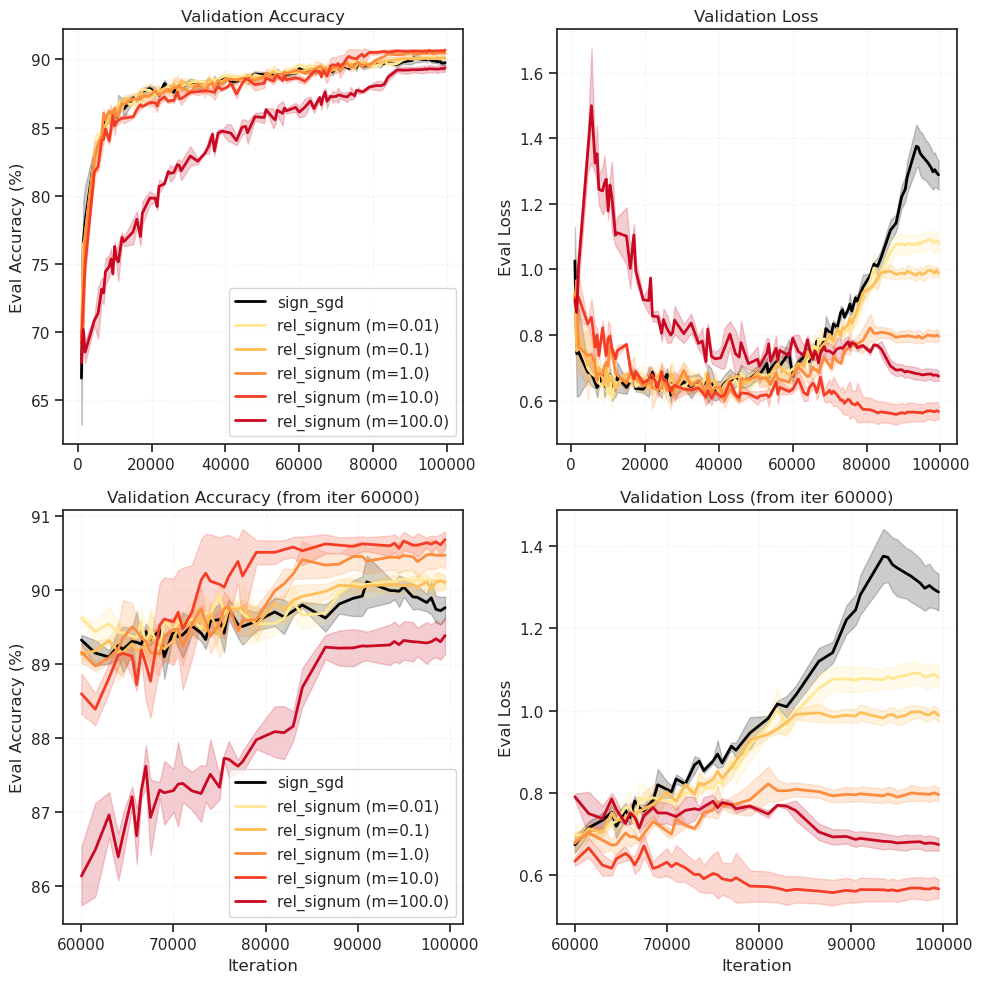

In [16]:
_ = plot_optimizer_comparison(
    grouped_data=grouped_data,
    save_path=fig_base_dir / 'signum_mass.png',
    color_map=color_map,
)

## Lion plot

In [17]:
df = df[df['state'] == 'finished']

In [18]:
filtered_df = filter_runs(
    df,
    optimizers=['rel_lion', 'lion'],
    lr=3e-3,
    beta1=0.95,
    beta2=0.99,
)

In [19]:
print_filtered_runs(
    filtered_df, 
    title="rel_signum vs sign_sgd (beta1=0.95, lr=1e-3)"
)


rel_signum vs sign_sgd (beta1=0.95, lr=1e-3)

Total: 20 runs

optimizer learning_rate beta1 beta2    mass  seed best_val_acc final_val_acc   run_id
     lion         3e-03 0.950 0.990   0.100     0        90.94         90.62 phthi4n0
     lion         3e-03 0.950 0.990   0.100     1        91.04         90.99 mry6njuc
     lion         3e-03 0.950 0.990   0.100     2        90.94         90.81 wsyydzqh
 rel_lion         3e-03 0.950 0.990   0.010     0        90.96         90.83 s7m2iozn
 rel_lion         3e-03 0.950 0.990   0.010     1        90.73         90.59 udxag64z
 rel_lion         3e-03 0.950 0.990   0.100     0        90.72         90.67 q8nrkua4
 rel_lion         3e-03 0.950 0.990   0.100     1        91.13         91.03 6kyhhcvx
 rel_lion         3e-03 0.950 0.990   0.100     2        91.18         91.09 x15xx1er
 rel_lion         3e-03 0.950 0.990   1.000     0        91.61         91.55 2wsr3rff
 rel_lion         3e-03 0.950 0.990   1.000     0        90.88         90.79 

In [20]:
history_keys = [
    'iter',
    '_step',
    'train/loss',
    'train/grad_norm',
    'eval/acc',
    'eval/loss',
    'eval/best_acc',
]

run_histories = fetch_multiple_run_histories(
    filtered_df,
    entity='pal-lab',
    project='GRA-CIFAR10',
    keys=history_keys,
    verbose=True,
)

Fetching 2wsr3rff: rel_lion, mass=1.0, seed=0
Fetching vuc0ubc9: rel_lion, mass=1.0, seed=1
Fetching dfyxne4d: rel_lion, mass=1.0, seed=2
Fetching s7m2iozn: rel_lion, mass=0.01, seed=0
Fetching q8nrkua4: rel_lion, mass=0.1, seed=0
Fetching y3ng1ugk: rel_lion, mass=1.0, seed=0
Fetching wxhzi36k: rel_lion, mass=10.0, seed=0
Fetching 6tt5ulxb: rel_lion, mass=100.0, seed=0
Fetching udxag64z: rel_lion, mass=0.01, seed=1
Fetching 6kyhhcvx: rel_lion, mass=0.1, seed=1
Fetching i7bbos9l: rel_lion, mass=1.0, seed=1
Fetching 3jvj9cra: rel_lion, mass=10.0, seed=1
Fetching l9w9iic1: rel_lion, mass=100.0, seed=1
Fetching x15xx1er: rel_lion, mass=0.1, seed=2
Fetching 24btea5e: rel_lion, mass=1.0, seed=2
Fetching iesyfl39: rel_lion, mass=10.0, seed=2
Fetching t52yufoh: rel_lion, mass=100.0, seed=2
Fetching phthi4n0: lion, mass=0.1, seed=0
Fetching mry6njuc: lion, mass=0.1, seed=1
Fetching wsyydzqh: lion, mass=0.1, seed=2


In [21]:
grouped_data = collections.defaultdict(list)

for run_id, data in run_histories.items():
    config = data['config']
    history = data['history']
    
    opt = config.get('optimizer')
    mass = config.get('mass')
    
    # Create a key that distinguishes rel_signum masses
    if opt == 'rel_lion' and mass is not None:
        key = f"rel_lion (m={mass})"
    else:
        key = opt
    
    grouped_data[key].append({
        'seed': config.get('seed'),
        'history': history,
        'config': config,
    })
    
grouped_data = dict(sorted(list(grouped_data.items())))

In [22]:
for key, runs in sorted(grouped_data.items()):
    seeds = [r['seed'] for r in runs]
    print(f"{key}:\t{len(runs)} runs, seeds={seeds}")

lion:   3 runs, seeds=[0, 1, 2]

rel_lion (m=0.01):      2 runs, seeds=[0, 1]

rel_lion (m=0.1):       3 runs, seeds=[0, 1, 2]

rel_lion (m=1.0):       6 runs, seeds=[0, 1, 2, 0, 1, 2]

rel_lion (m=10.0):      3 runs, seeds=[0, 1, 2]

rel_lion (m=100.0):     3 runs, seeds=[0, 1, 2]

In [23]:
for key, runs in sorted(grouped_data.items()):
    print(f"\n{key}:")
    for run in runs:
        h = run['history']
        seed = run['seed']
        
        # Get eval accuracy (non-null values only)
        eval_acc = h[['iter', 'eval/acc']].dropna()
        
        if len(eval_acc) > 0:
            final_acc = eval_acc['eval/acc'].iloc[-1]
            best_acc = eval_acc['eval/acc'].max()
            n_evals = len(eval_acc)
            print(f"  seed={seed}: {n_evals} evals, best={best_acc:.2f}, final={final_acc:.2f}")
        else:
            print(f"  seed={seed}: no eval data")

lion:

seed=0: 100 evals, best=90.94, final=90.76

seed=1: 100 evals, best=91.04, final=90.90

seed=2: 100 evals, best=90.94, final=90.94

rel_lion (m=0.01):

...

seed=2: 100 evals, best=90.58, final=90.52

rel_lion (m=100.0):

seed=0: 100 evals, best=91.00, final=91.00

seed=1: 100 evals, best=91.22, final=91.09

seed=2: 100 evals, best=91.11, final=90.91

### no reorder neede, just plot

In [24]:
list(grouped_data)

['lion',
 'rel_lion (m=0.01)',
 'rel_lion (m=0.1)',
 'rel_lion (m=1.0)',
 'rel_lion (m=10.0)',
 'rel_lion (m=100.0)']

In [25]:
cmap = 'YlOrRd'# 'YlOrBr'

rel_keys = sorted([k for k in grouped_data.keys() if 'rel_' in k])

colors = sns.color_palette(
    n_colors=len(rel_keys), palette=cmap)

color_map = {
    k: colors[i] for i, k
    in enumerate(rel_keys)
}
color_map['lion'] = 'k'

Saved to /home/hadi/Dropbox/git/jb-progress-2026/figs/lion_mass.png

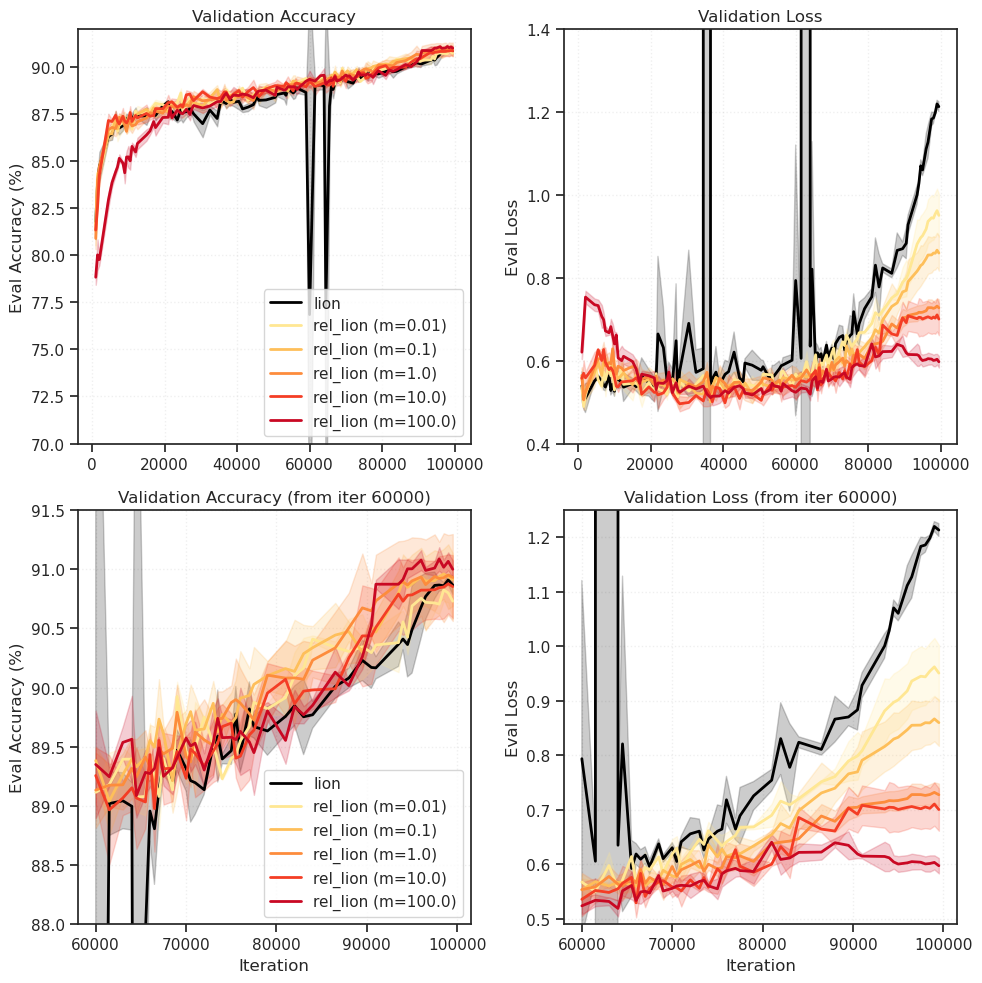

In [26]:
ylims = [(70, 92), (0.4, 1.4), (88, 91.5), (0.49, 1.25)]


_ = plot_optimizer_comparison(
    grouped_data=grouped_data,
    save_path=fig_base_dir / 'lion_mass.png',
    color_map=color_map,
    ylims=ylims,
)

## Best models plot

In [27]:
df = fetch_runs(entity='pal-lab', project='GRA-CIFAR10')
df = df[df['state'] == 'finished']  # only finished runs

Fetching runs from: pal-lab/GRA-CIFAR10
Found 700 runs
Processed 698 runs (after filtering)


In [28]:
# only lr = 3e-3
df = df.loc[df['learning_rate'] == 3e-3]

In [29]:
group_cols = ['optimizer', 'learning_rate', 'beta1', 'beta2', 'mass']
group_cols = [c for c in group_cols if c in df.columns]

In [30]:
config_stats = df.groupby(group_cols, dropna=False).agg({
    'best_val_acc': ['mean', 'std', 'count'],
    'run_id': list,  # keep track of run_ids for each config
}).reset_index()


# Flatten columns
config_stats.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col 
    for col in config_stats.columns
]


# For each optimizer, find the config with best mean accuracy
best_configs = []
for opt in config_stats['optimizer'].unique():
    opt_df = config_stats[config_stats['optimizer'] == opt]
    best_idx = opt_df['best_val_acc_mean'].idxmax()
    best_configs.append(opt_df.loc[best_idx])


best_df = pd.DataFrame(best_configs)
print("Best config per optimizer:")
print(best_df[['optimizer', 'learning_rate', 'beta1', 'beta2', 'mass', 'best_val_acc_mean', 'best_val_acc_count']])

Best config per optimizer:

optimizer  learning_rate  beta1  beta2   mass  best_val_acc_mean  \
3        adamw          0.003   0.80  0.999    0.1          91.316664   
16        lion          0.003   0.95  0.990    0.1          90.973332   
23    rel_lion          0.003   0.50  0.990  100.0          91.554996   
61  rel_signum          0.003   0.90  0.950   10.0          91.109999   
73    sign_sgd          0.003   0.90  0.950    0.1          90.549997   

    best_val_acc_count  
3                    3  
16                   3  
23                   2  
61                   3  
73                   3

In [31]:
# Collect all run_ids from the best configs
best_run_ids = []
for _, row in best_df.iterrows():
    best_run_ids.extend(row['run_id_list'])

# Filter original df to just these runs
best_runs_df = df[df['run_id'].isin(best_run_ids)]
print(f"\nFetching {len(best_runs_df)} runs...")

# Fetch full histories
run_histories = fetch_multiple_run_histories(
    best_runs_df,
    entity='pal-lab',
    project='GRA-CIFAR10',
    verbose=True,
)

Fetching 14 runs...

Fetching 76pzm6jf: adamw, mass=0.1, seed=0
Fetching 2bse968i: adamw, mass=0.1, seed=1
Fetching t6mlwuhh: rel_signum, mass=10.0, seed=0
Fetching 3xl40d5t: adamw, mass=0.1, seed=2
Fetching nrib38m8: rel_signum, mass=10.0, seed=1
Fetching vcg0qab0: rel_signum, mass=10.0, seed=2
Fetching phthi4n0: lion, mass=0.1, seed=0
Fetching mry6njuc: lion, mass=0.1, seed=1
Fetching wsyydzqh: lion, mass=0.1, seed=2
Fetching 6sn5k3u5: sign_sgd, mass=0.1, seed=0
Fetching xfm0r8lf: sign_sgd, mass=0.1, seed=1
Fetching e8ldn9ph: rel_lion, mass=100.0, seed=0
Fetching g2m4ee42: rel_lion, mass=100.0, seed=1
Fetching hui67tup: sign_sgd, mass=0.1, seed=2


In [32]:
grouped_data = collections.defaultdict(list)

for run_id, data in run_histories.items():
    config = data['config']
    history = data['history']
    
    opt = config.get('optimizer')
    grouped_data[opt].append({
        'seed': config.get('seed'),
        'history': history,
        'config': config,
    })

grouped_data = dict(sorted(list(grouped_data.items())))


print("\nGrouped runs:")
for key, runs in grouped_data.items():
    print(f"  {key}: {len(runs)} runs")

Grouped runs:

adamw: 3 runs

lion: 3 runs

rel_lion: 2 runs

rel_signum: 3 runs

sign_sgd: 3 runs

In [33]:
tab20 = sns.color_palette('tab20')
tab20

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (1.0, 0.7333333333333333, 0.47058823529411764),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (1.0, 0.596078431372549, 0.5882352941176471),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.7725490196078432, 0.6901960784313725, 0.8352941176470589),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.7686274509803922, 0.611764705882353, 0.5803921568627451),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.9686274509803922, 0.7137254901960784, 0.8235294117647058),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7803921568627451, 0.7803921568627451, 0.7803921568627451),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.8588235294117647, 0.8588235294117647, 0.5529411764705883),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529),
 (0.6196078431372549, 0.8549019607843137, 0.8980392156862745)]

Saved to /home/hadi/Dropbox/git/jb-progress-2026/figs/best_fits.png

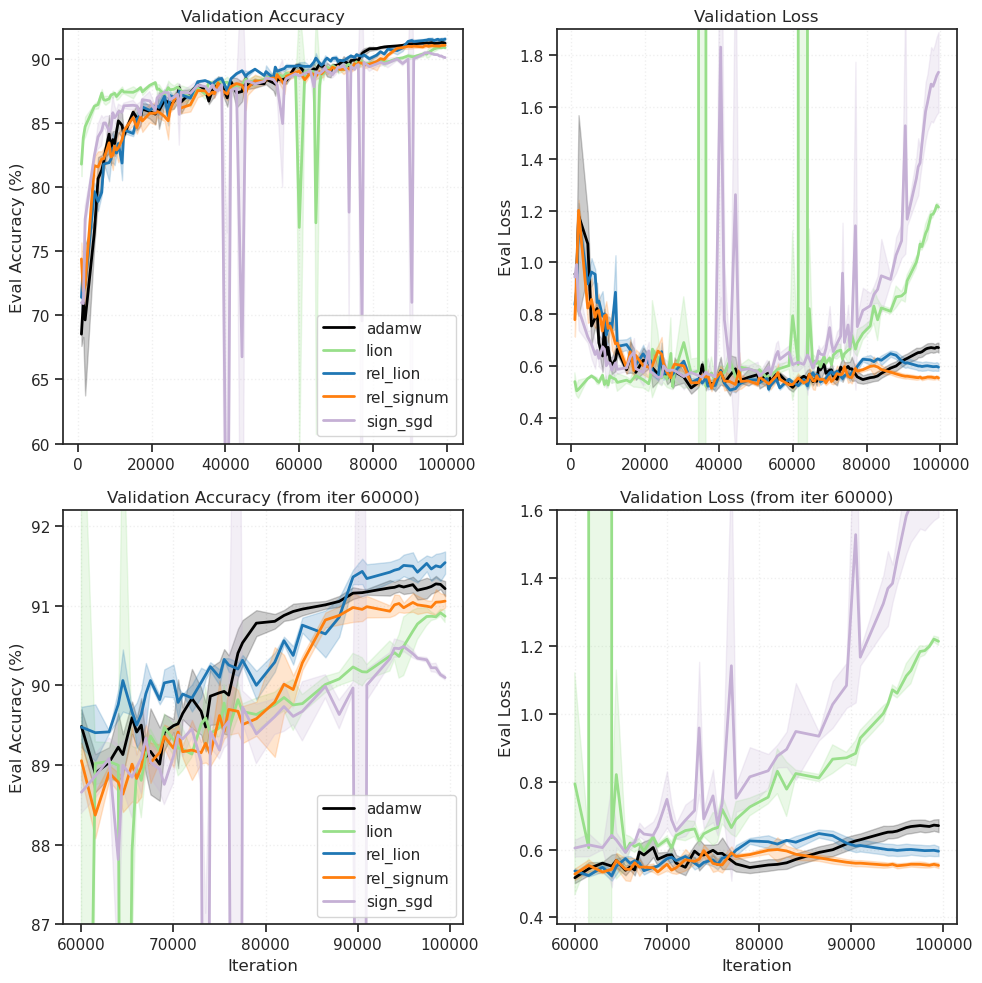

In [34]:
ylims = [(60, 92.3), (0.3, 1.9), (87, 92.2), (0.38, 1.6)]


# Define your custom color map
color_map = {
    'rel_lion': list(tab20)[0],
    'lion': list(tab20)[5],
    #
    'rel_signum': list(tab20)[2],
    'sign_sgd': list(tab20)[9],
    #
    'adamw': 'k',
}

fig, axes = plot_optimizer_comparison(
    grouped_data=grouped_data,
    save_path=fig_base_dir / 'best_fits.png',
    zoom_start_iter=60000,
    color_map=color_map,
    ylims=ylims,
)

## Signum robustness (lr) plot